# Uber Trip Analysis & Demand Prediction

## 1. Project Overview
## 2. Business Problem
## 3. Dataset Description
## 4. Tools & Technologies Used
## 5. Importing Required Libraries
## 6. Data Loading
## 7. Data Preprocessing
## 8. Exploratory Data Analysis (EDA)
## 9. Feature Engineering
## 10. Train-Test Split (Time Series)
## 11. Model Building
## 12. Model Evaluation
## 13. Ensemble Model
## 14. Insights & Conclusion


# 1. Project Overview
### This project analyzes Uber pickup data from New York City to identify temporal demand patterns and build machine learning models to forecast hourly trip demand. The goal is to support demand prediction for operational and business decision-making.

# 2. Business Platform

## Accurate demand forecasting is critical for ride-hailing platforms to:
 - Optimize driver allocation
 - Reduce passenger wait times
 - Improve surge pricing strategies

#### This project aims to predict hourly Uber trip demand using historical data.

# 3. Dataset Description
### The dataset contains Uber pickup records from NYC (April–September 2014). Each record includes pickup timestamp, latitude, longitude, and base code.


# 4. Tools & Technologies
- Python
- Jupyter Notebook
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn, XGBoost
- Git & GitHub

In [4]:
# 5. Importing required libraries
 
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from datetime import datetime 

pd.set_option('display.max_columns',None)

sns.set(style='whitegrid')

In [8]:
## Data Loading

import os

data_path = "data"
df_list=[]

csv_files = [file for file in os.listdir(data_path) if file.endswith('.csv')]

for file in csv_files:
    df = pd.read_csv(os.path.join(data_path,file))
    df_list.append(df)

uber_df= pd.concat(df_list, ignore_index = True)

In [9]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB


In [10]:
uber_df.describe()

,Lat,Lon
count,4.534327e+06,4.534327e+06
mean,4.073926e+01,-7.397302e+01
std,3.994991e-02,5.726670e-02
min,3.965690e+01,-7.492900e+01
25%,4.072110e+01,-7.399650e+01
50%,4.074220e+01,-7.398340e+01
75%,4.076100e+01,-7.396530e+01
max,4.211660e+01,-7.206660e+01


In [12]:
print(df.head())

          Date/Time      Lat      Lon    Base
0  9/1/2014 0:01:00  40.2201 -74.0021  B02512
1  9/1/2014 0:01:00  40.7500 -74.0027  B02512
2  9/1/2014 0:03:00  40.7559 -73.9864  B02512
3  9/1/2014 0:06:00  40.7450 -73.9889  B02512
4  9/1/2014 0:11:00  40.8145 -73.9444  B02512


In [28]:
uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'])
print(uber_df.head(30))

             Date/Time      Lat      Lon    Base  Hour  Day  DayofWeek  Month
0  2014-04-01 00:11:00  40.7690 -73.9549  B02512     0    1          1      4
1  2014-04-01 00:17:00  40.7267 -74.0345  B02512     0    1          1      4
2  2014-04-01 00:21:00  40.7316 -73.9873  B02512     0    1          1      4
3  2014-04-01 00:28:00  40.7588 -73.9776  B02512     0    1          1      4
4  2014-04-01 00:33:00  40.7594 -73.9722  B02512     0    1          1      4
5  2014-04-01 00:33:00  40.7383 -74.0403  B02512     0    1          1      4
6  2014-04-01 00:39:00  40.7223 -73.9887  B02512     0    1          1      4
7  2014-04-01 00:45:00  40.7620 -73.9790  B02512     0    1          1      4
8  2014-04-01 00:55:00  40.7524 -73.9960  B02512     0    1          1      4
9  2014-04-01 01:01:00  40.7575 -73.9846  B02512     1    1          1      4
10 2014-04-01 01:19:00  40.7256 -73.9869  B02512     1    1          1      4
11 2014-04-01 01:48:00  40.7591 -73.9684  B02512     1    1     

In [20]:
uber_df['Hour'] = uber_df['Date/Time'].dt.hour
uber_df['Day'] = uber_df['Date/Time'].dt.day
uber_df['DayofWeek'] = uber_df['Date/Time'].dt.dayofweek
uber_df['Month']=uber_df['Date/Time'].dt.month

In [21]:
uber_df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
Hour         0
Day          0
DayofWeek    0
Month        0
dtype: int64

In [29]:
uber_df = uber_df.sort_values('Date/Time')

In [31]:
uber_df.to_csv("data/uber_cleaned.csv",index = False)

## 8. Exploratory Data Analysis (EDA)




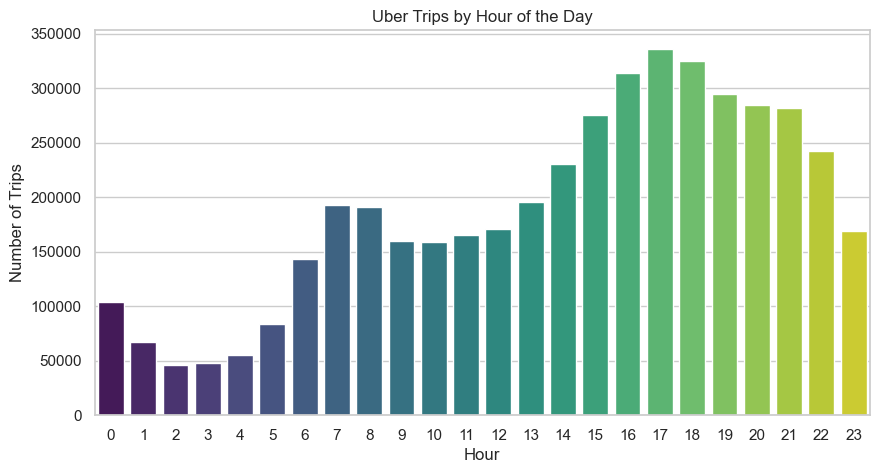

In [40]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Hour', data=uber_df, palette='viridis')
plt.title('Uber Trips by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.savefig("results/hourly_trips.png")
plt.show()

**Insight:**  
Uber demand peaks during evening hours, indicating strong commuting behavior.


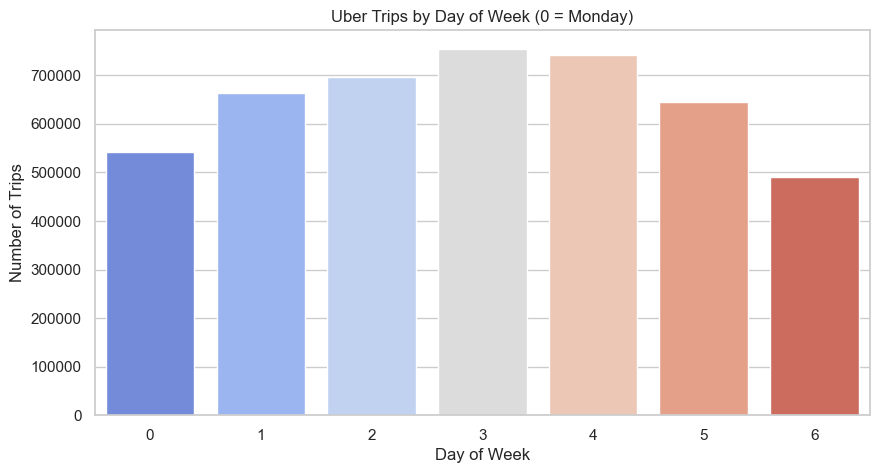

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(x='DayofWeek', data=uber_df, palette='coolwarm')
plt.title('Uber Trips by Day of Week (0 = Monday)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.savefig("results/Weekly_trips.png")
plt.show()


**Insight:**  
Weekdays show higher demand compared to weekends, reflecting
work-related travel patterns.


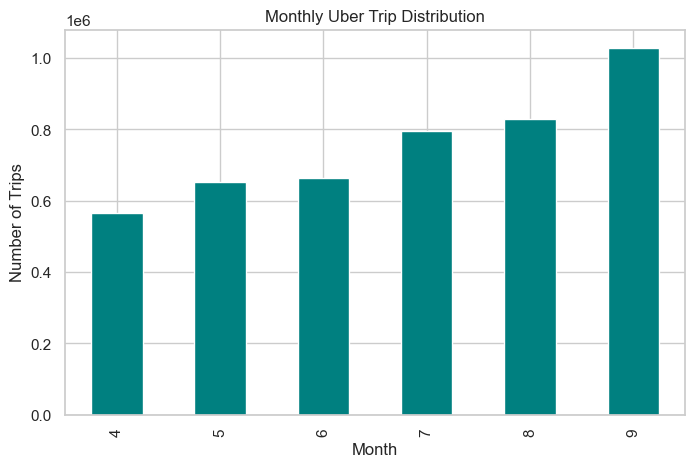

In [42]:
monthly_trips = uber_df.groupby('Month').size()

plt.figure(figsize=(8, 5))
monthly_trips.plot(kind='bar', color='teal')
plt.title('Monthly Uber Trip Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.savefig("results/monthly_trips.png")
plt.show()


**Insight:**  
Uber demand increases steadily from April to September


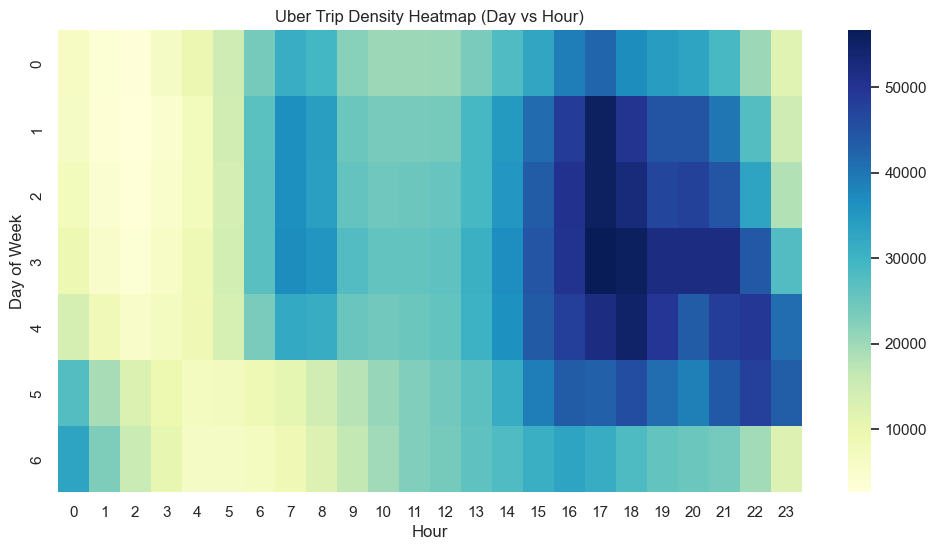

In [43]:
heatmap_data = uber_df.groupby(['DayofWeek', 'Hour']).size().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Uber Trip Density Heatmap (Day vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.savefig("results/heatmap(day and week combined)_trips.png")
plt.show()


**Insight:**  
Peak demand occurs during weekday evenings 4pm-9pm, highlighting commuter-driven usage patterns.


## 9. Feature Engineering & Time-Series Preparation


In [44]:
# Create hourly trip counts
hourly_df = uber_df.set_index('Date/Time').resample('H').size()

# Convert to DataFrame
hourly_df = hourly_df.reset_index()
hourly_df.columns = ['DateTime', 'Trip_Count']

hourly_df.head()

,DateTime,Trip_Count
0,2014-04-01 00:00:00,138
1,2014-04-01 01:00:00,66
2,2014-04-01 02:00:00,53
3,2014-04-01 03:00:00,93
4,2014-04-01 04:00:00,166


In [45]:
hourly_df['Hour'] = hourly_df['DateTime'].dt.hour
hourly_df['Day'] = hourly_df['DateTime'].dt.day
hourly_df['DayOfWeek'] = hourly_df['DateTime'].dt.dayofweek
hourly_df['Month'] = hourly_df['DateTime'].dt.month


In [50]:
#Lag = last 24 hours
for lag in range(1, 25):
    hourly_df[f'lag_{lag}'] = hourly_df['Trip_Count'].shift(lag)
hourly_df.dropna(inplace=True)
hourly_df.reset_index(drop=True, inplace=True)


In [51]:
hourly_df.info()
hourly_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4319 entries, 0 to 4318
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DateTime    4319 non-null   datetime64[ns]
 1   Trip_Count  4319 non-null   int64         
 2   Hour        4319 non-null   int32         
 3   Day         4319 non-null   int32         
 4   DayOfWeek   4319 non-null   int32         
 5   Month       4319 non-null   int32         
 6   lag_1       4319 non-null   float64       
 7   lag_2       4319 non-null   float64       
 8   lag_3       4319 non-null   float64       
 9   lag_4       4319 non-null   float64       
 10  lag_5       4319 non-null   float64       
 11  lag_6       4319 non-null   float64       
 12  lag_7       4319 non-null   float64       
 13  lag_8       4319 non-null   float64       
 14  lag_9       4319 non-null   float64       
 15  lag_10      4319 non-null   float64       
 16  lag_11      4319 non-nul

,DateTime,Trip_Count,Hour,Day,DayOfWeek,Month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
0,2014-04-04 00:00:00,329,0,4,4,4,793.0,1580.0,1714.0,1591.0,1374.0,1628.0,1640.0,1438.0,1247.0,934.0,766.0,619.0,549.0,558.0,591.0,864.0,1022.0,750.0,354.0,193.0,130.0,66.0,106.0,194.0
1,2014-04-04 01:00:00,184,1,4,4,4,329.0,793.0,1580.0,1714.0,1591.0,1374.0,1628.0,1640.0,1438.0,1247.0,934.0,766.0,619.0,549.0,558.0,591.0,864.0,1022.0,750.0,354.0,193.0,130.0,66.0,106.0
2,2014-04-04 02:00:00,117,2,4,4,4,184.0,329.0,793.0,1580.0,1714.0,1591.0,1374.0,1628.0,1640.0,1438.0,1247.0,934.0,766.0,619.0,549.0,558.0,591.0,864.0,1022.0,750.0,354.0,193.0,130.0,66.0
3,2014-04-04 03:00:00,154,3,4,4,4,117.0,184.0,329.0,793.0,1580.0,1714.0,1591.0,1374.0,1628.0,1640.0,1438.0,1247.0,934.0,766.0,619.0,549.0,558.0,591.0,864.0,1022.0,750.0,354.0,193.0,130.0
4,2014-04-04 04:00:00,238,4,4,4,4,154.0,117.0,184.0,329.0,793.0,1580.0,1714.0,1591.0,1374.0,1628.0,1640.0,1438.0,1247.0,934.0,766.0,619.0,549.0,558.0,591.0,864.0,1022.0,750.0,354.0,193.0


In [52]:
hourly_df.tail()

,DateTime,Trip_Count,Hour,Day,DayOfWeek,Month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
4314,2014-09-30 18:00:00,2625,18,30,1,9,2682.0,2370.0,2128.0,1704.0,1538.0,1176.0,1214.0,1183.0,1274.0,1866.0,2030.0,1582.0,867.0,415.0,235.0,129.0,165.0,290.0,609.0,1103.0,1509.0,1727.0,1792.0,2053.0
4315,2014-09-30 19:00:00,2404,19,30,1,9,2625.0,2682.0,2370.0,2128.0,1704.0,1538.0,1176.0,1214.0,1183.0,1274.0,1866.0,2030.0,1582.0,867.0,415.0,235.0,129.0,165.0,290.0,609.0,1103.0,1509.0,1727.0,1792.0
4316,2014-09-30 20:00:00,2246,20,30,1,9,2404.0,2625.0,2682.0,2370.0,2128.0,1704.0,1538.0,1176.0,1214.0,1183.0,1274.0,1866.0,2030.0,1582.0,867.0,415.0,235.0,129.0,165.0,290.0,609.0,1103.0,1509.0,1727.0
4317,2014-09-30 21:00:00,1961,21,30,1,9,2246.0,2404.0,2625.0,2682.0,2370.0,2128.0,1704.0,1538.0,1176.0,1214.0,1183.0,1274.0,1866.0,2030.0,1582.0,867.0,415.0,235.0,129.0,165.0,290.0,609.0,1103.0,1509.0
4318,2014-09-30 22:00:00,1347,22,30,1,9,1961.0,2246.0,2404.0,2625.0,2682.0,2370.0,2128.0,1704.0,1538.0,1176.0,1214.0,1183.0,1274.0,1866.0,2030.0,1582.0,867.0,415.0,235.0,129.0,165.0,290.0,609.0,1103.0


In [53]:
#Save Processed Dataset
hourly_df.to_csv('data/hourly_features.csv',index = False)

In [54]:
hourly_df = hourly_df.sort_values('DateTime')

## Splitting the data for training and testing the model

In [56]:
y = hourly_df['Trip_Count']
x= hourly_df.drop(columns=['DateTime','Trip_Count'])

In [58]:
#splitting data as 80% for training and 20% for testing
split_index = int(len(hourly_df)*0.8)

x_train = x.iloc[:split_index]
x_test = x.loc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.loc[split_index:]

In [62]:
print("Trainning period")
print(hourly_df.iloc[:split_index]['DateTime'].min() ,"to", hourly_df.iloc[:split_index]['DateTime'].max())

print("Testing Period")
print(hourly_df.iloc[split_index:]['DateTime'].min(), "to", hourly_df.iloc[split_index:]['DateTime'].max())

Trainning period
2014-04-04 00:00:00 to 2014-08-25 22:00:00
Testing Period
2014-08-25 23:00:00 to 2014-09-30 22:00:00


## Model Building

In [63]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

### Models Used

- **Random Forest Regressor**:  
  Handles non-linear relationships well and is robust to noise.

- **Gradient Boosting Regressor**:  
  Builds models sequentially to correct previous errors, often achieving
  higher accuracy on structured data.

These models are well-suited for time-series demand forecasting with
engineered lag features.


In [64]:
rf_model = RandomForestRegressor(
n_estimators = 100,
random_state = 42,
n_jobs = -1
)

rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

In [65]:
rf_mape = mean_absolute_percentage_error(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds, squared=False)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest MAPE: {rf_mape:.2%}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R2: {rf_r2:.2f}")


Random Forest MAPE: 10.37%
Random Forest RMSE: 177.70
Random Forest R2: 0.95


## Train Gradient Boosting Model

In [71]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gbr_model.fit(x_train, y_train)

gbr_preds = gbr_model.predict(x_test)


In [72]:
gbr_mape = mean_absolute_percentage_error(y_test, gbr_preds)
gbr_rmse = mean_squared_error(y_test, gbr_preds, squared=False)
gbr_r2 = r2_score(y_test, gbr_preds)

print(f"Gradient Boosting MAPE: {gbr_mape:.2%}")
print(f"Gradient Boosting RMSE: {gbr_rmse:.2f}")
print(f"Gradient Boosting R2: {gbr_r2:.2f}")


Gradient Boosting MAPE: 10.70%
Gradient Boosting RMSE: 174.76
Gradient Boosting R2: 0.95


### Model Performance Comparison

| Model             | MAPE  | RMSE   |  R²  |
|-------------------|-------|--------|------|
| Random Forest     | 10.37 | 177.70 | 0.95 |
| Gradient Boosting | 10.70 | 174.76 | 0.95 |

Gradient Boosting generally performs better due to its ability to
capture complex temporal patterns.


## 📊 Model Results

The Random Forest regression and Gradient boosting regression model was trained using lag-based time-series features to predict hourly Uber trip demand. The model was evaluated on a held-out 20% test set.

### 🔍 Evaluation Metrics
- **MAPE:**  — average prediction error of approximately 10%
- **RMSE:**  — typical deviation of 178/175 trips per hour
- **R² Score:**  — model explains 95% of the variance in demand

### 📈 Observations
- The modelseffectively captures daily and short-term demand patterns.
- High R² indicates strong explanatory power without data leakage.
- Prediction errors increase during sudden demand spikes, which is expected in real-world scenarios.



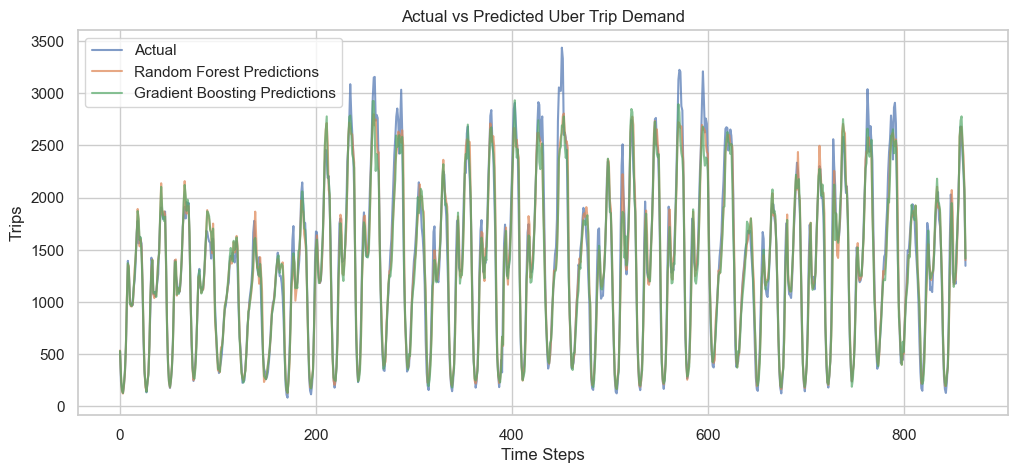

In [74]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(rf_preds, label='Random Forest Predictions', alpha=0.7)
plt.plot(gbr_preds, label='Gradient Boosting Predictions', alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Uber Trip Demand")
plt.xlabel("Time Steps")
plt.ylabel("Trips")
plt.savefig("results/Actual_Vs_Predicted_Trip_demand(RFP & GBP).png")
plt.show()


## 12. Ensemble Model & Final Evaluation

In [80]:
# Convert MAPE to weights (lower error = higher weight)
rf_weight = 1 / rf_mape
gbr_weight = 1 / gbr_mape

total_weight = rf_weight + gbr_weight

rf_weight /= total_weight
gbr_weight /= total_weight

#rf_mape, gbr_mape,rf_weight,gbr_weight,total_weight
rf_weight, gbr_weight


(0.10367286621943693,
 0.10702029778104415,
 0.5079438542239547,
 0.4920561457760453,
 18.989747251771714)

In [81]:
ensemble_preds = (rf_weight * rf_preds) + (gbr_weight * gbr_preds)

In [82]:
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_preds)
ensemble_rmse = mean_squared_error(y_test, ensemble_preds, squared=False)
ensemble_r2 = r2_score(y_test, ensemble_preds)

print(f"Ensemble MAPE: {ensemble_mape:.2%}")
print(f"Ensemble RMSE: {ensemble_rmse:.2f}")
print(f"Ensemble R2: {ensemble_r2:.2f}")


Ensemble MAPE: 10.32%
Ensemble RMSE: 171.27
Ensemble R2: 0.95


# Final Model Performance Comparison

| Model             | MAPE  | RMSE   |  R²  |
|-------------------|-------|--------|------|
| Random Forest     | 10.37 | 177.70 | 0.95 |
| Gradient Boosting | 10.70 | 174.76 | 0.95 |
| Ensemble Modeling | 10.32 | 171.27 | 0.95 |

The ensemble model demonstrates improved or comparable performance, validating the benefit of combining models.


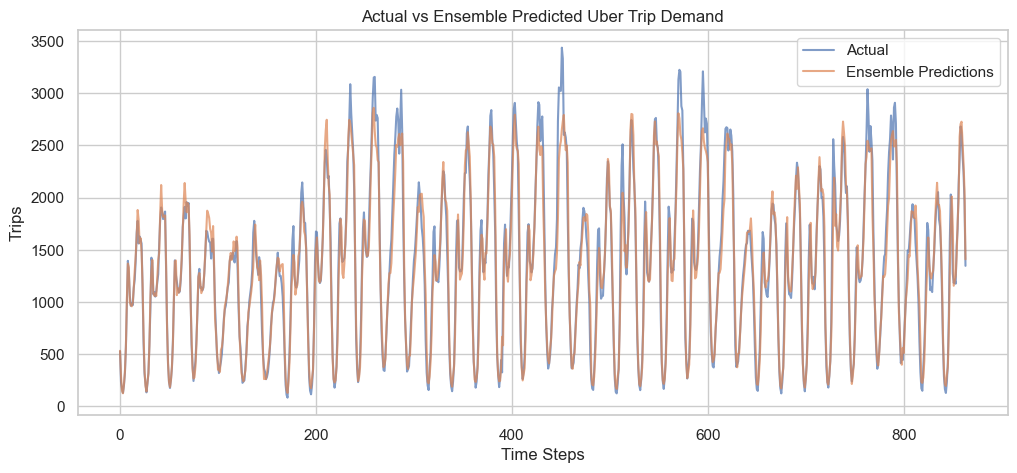

In [84]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(ensemble_preds, label='Ensemble Predictions', alpha=0.7)
plt.legend()
plt.title("Actual vs Ensemble Predicted Uber Trip Demand")
plt.xlabel("Time Steps")
plt.ylabel("Trips")
plt.savefig("results/Actual_Vs_Ensemble_Predicted_Trip_demand.png")
plt.show()
